# 99_slot_effects — Winner 슬롯 OAT (One-At-a-Time) 효과 분석

**목적**: 자동 식별된 winner 의 **한 슬롯만 변경** 했을 때 sharpe / sortino / mdd 가 어떻게 변하는지 시각화.

**OAT 원칙**: 4 슬롯 (prior / pw / q / om) 중 1 개만 변경하고 나머지 3 개는 winner 값으로 고정. p (변동성 출처) 는 90 매트릭스 전부 'ls' (LSTM 앙상블) 단일 → OAT 대상 제외.

## 슬롯 정의 + OAT 옵션

| 슬롯 | 설명 | 옵션 (5+3+3+2=13 개) |
|---|---|---|
| **prior** | 시장 균형 prior π | mcap / eq / rp |
| **pw** | P 가중치 weighting | mcap / eq / rp |
| **q** | view 강도 Q 모드 | fix / lam / raw / inv / vsp |
| **om** | view 분산 Ω 모드 | he / pap |

→ winner (`mat_eq_eq_raw_pap`) 의 OAT 변형: prior 2 + pw 2 + q 4 + om 1 = 9 개 + winner = 10 pkl

## 시각화 구조

**3 행 × 4 열 grouped bar**:
- 행: Sharpe (TEST 168m) / Sortino (TEST 168m) / MDD (TEST 168m)
- 열: prior / pw / q / om
- 각 subplot: x = 그 슬롯의 옵션, y = metric, ★ = winner 옵션

K_CUT (2023-12-31, TEST 168m) 기준 — 05b 의 winner 선정 기준과 동일.

---

**관련 가이드**:
- [PROJECT_OVERVIEW.md](../docs/PROJECT_OVERVIEW.md) (전체 파이프라인)
- [SENSITIVITY_ANALYSIS.md](../docs/SENSITIVITY_ANALYSIS.md) — Q·PCT 민감도와 보완 관계 (Q·PCT 는 winner 의 *내부 파라미터*, OAT 는 *슬롯 카테고리* 변경)

In [1]:
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import platform
from pathlib import Path

# 한글 폰트
if platform.system() == 'Darwin':
    plt.rcParams['font.family'] = 'sans-serif'
    plt.rcParams['font.sans-serif'] = ['AppleGothic', 'Apple SD Gothic Neo', 'NanumGothic', 'Arial Unicode MS', 'DejaVu Sans']
elif platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'sans-serif'
    plt.rcParams['font.sans-serif'] = ['Malgun Gothic', 'Arial Unicode MS', 'DejaVu Sans']
else:
    plt.rcParams['font.family'] = 'sans-serif'
    plt.rcParams['font.sans-serif'] = ['NanumGothic', 'Noto Sans CJK KR', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

import sys
BASE_DIR    = Path.cwd().parent   # appendix/ → final_pt/
sys.path.insert(0, str(BASE_DIR))   # final_pt/ 에서 모듈 import
RESULTS_DIR = BASE_DIR / 'results'
OUT_DIR     = BASE_DIR / 'outputs' / '99_slot_effects'
OUT_DIR.mkdir(parents=True, exist_ok=True)

# rf / spy 로드
panel = pd.read_csv(BASE_DIR / 'data' / 'monthly_panel.csv', parse_dates=['date']).set_index(['date','ticker'])
rf      = panel['rf_1m'].groupby(level='date').first()
spy_ret = panel['spy_ret'].groupby(level='date').first()

# master / regime table 빌드 (K_CUT 적용은 build_master_table 의 eval_periods 가 자동 처리)
import importlib, master_table
importlib.reload(master_table)
from master_table import build_master_table, build_regime_table, identify_winner, REGIMES

mt = build_master_table(RESULTS_DIR, rf, spy_ret, periods={l:(s,e) for l,s,e in REGIMES})
rt = build_regime_table(mt, RESULTS_DIR, rf, regimes=REGIMES)

# 90 매트릭스 슬롯만 필터 (sensitivity sweep 제외)
mask = ~(mt['name'].str.endswith(('_q55','_q64','_q70')) | mt['name'].str.startswith('winner_'))
mt = mt[mask].copy()
rt = rt[mask].copy()
print(f'mt: {len(mt)}개 (90 매트릭스 슬롯)')

# Winner 자동 식별 — sortino_TEST 기준 (K_CUT 168m, 05b 와 동일)
_w = identify_winner(mt, rt, ir_threshold=10.0, sortino_key='sortino_TEST')
WINNER_NAME = _w['name']
winner_row = mt[mt['name']==WINNER_NAME].iloc[0]
WINNER_SLOTS = {
    'prior': winner_row['prior_s'],
    'pw'   : winner_row['pw_s'],
    'q'    : winner_row['q_s'],
    'om'   : winner_row['om_s'],
}
print(f'\n★ Winner: {WINNER_NAME}')
print(f'  canonical: {winner_row["canonical"]}')
print(f'  슬롯값: prior={WINNER_SLOTS["prior"]}, pw={WINNER_SLOTS["pw"]}, q={WINNER_SLOTS["q"]}, om={WINNER_SLOTS["om"]}')
print(f'  sortino_TEST = {winner_row["sortino_TEST"]:.3f}, sharpe_TEST = {winner_row["sharpe_TEST"]:.3f}, mdd_TEST = {winner_row["mdd_TEST"]*100:.2f}%')

mt: 90개 (90 매트릭스 슬롯)

★ Winner: mat_eq_eq_raw_pap
  canonical: eq_ls_eq_raw_pap
  슬롯값: prior=eq, pw=eq, q=raw, om=pap
  sortino_TEST = 1.853, sharpe_TEST = 1.097, mdd_TEST = -13.65%


In [2]:
# OAT 변형 식별 — 한 슬롯만 변경, 나머지 3 슬롯은 winner 고정
DIM_OPTIONS = {
    'prior': ['mcap', 'eq', 'rp'],
    'pw'   : ['mcap', 'eq', 'rp'],
    'q'    : ['fix', 'lam', 'raw', 'inv', 'vsp'],
    'om'   : ['he', 'pap'],
}
DIM_TO_COL = {'prior': 'prior_s', 'pw': 'pw_s', 'q': 'q_s', 'om': 'om_s'}

# 각 dim 별로 OAT 후보 추출
oat_data = {}
for dim, options in DIM_OPTIONS.items():
    rows = []
    other_dims = [d for d in ['prior','pw','q','om'] if d != dim]
    for opt in options:
        # winner 의 다른 슬롯 그대로, 이 dim 만 opt 로
        query = {DIM_TO_COL[d]: WINNER_SLOTS[d] for d in other_dims}
        query[DIM_TO_COL[dim]] = opt
        mask = pd.Series([True]*len(mt), index=mt.index)
        for col, val in query.items():
            mask &= (mt[col] == val)
        sub = mt[mask]
        if len(sub) == 1:
            r = sub.iloc[0]
            rows.append({
                'option'     : opt,
                'name'       : r['name'],
                'is_winner'  : r['name'] == WINNER_NAME,
                'sharpe'     : r['sharpe_TEST'],
                'sortino'    : r['sortino_TEST'],
                'mdd'        : r['mdd_TEST'],
            })
        elif len(sub) == 0:
            print(f'⚠️ {dim}={opt} 조합 pkl 부재 (winner 외 슬롯 고정 기준)')
        else:
            print(f'⚠️ {dim}={opt} 다중 매칭 {len(sub)}개 — skip')
    oat_data[dim] = pd.DataFrame(rows)

# 콘솔 표 출력
for dim, df_oat in oat_data.items():
    print(f'\n■ OAT — {dim} 슬롯 변형')
    fmt = df_oat.copy()
    fmt['mdd'] = (fmt['mdd']*100).map(lambda x: f'{x:.2f}%')
    fmt['sharpe'] = fmt['sharpe'].map(lambda x: f'{x:.3f}')
    fmt['sortino'] = fmt['sortino'].map(lambda x: f'{x:.3f}')
    fmt['mark'] = fmt['is_winner'].map(lambda x: '★' if x else '')
    print(fmt[['option','name','sharpe','sortino','mdd','mark']].to_string(index=False))


■ OAT — prior 슬롯 변형
option                name sharpe sortino     mdd mark
  mcap mat_mcap_eq_raw_pap  1.100   1.792 -14.73%     
    eq   mat_eq_eq_raw_pap  1.097   1.853 -13.65%    ★
    rp   mat_rp_eq_raw_pap  1.094   1.851 -13.75%     

■ OAT — pw 슬롯 변형
option                name sharpe sortino     mdd mark
  mcap mat_eq_mcap_raw_pap  0.989   1.658 -16.95%     
    eq   mat_eq_eq_raw_pap  1.097   1.853 -13.65%    ★
    rp   mat_eq_rp_raw_pap  1.070   1.792 -13.87%     

■ OAT — q 슬롯 변형
option              name sharpe sortino     mdd mark
   fix mat_eq_eq_fix_pap  1.092   1.733 -13.14%     
   lam mat_eq_eq_lam_pap  1.103   1.839 -13.65%     
   raw mat_eq_eq_raw_pap  1.097   1.853 -13.65%    ★
   inv mat_eq_eq_inv_pap  1.066   1.620 -17.57%     
   vsp mat_eq_eq_vsp_pap  1.074   1.728 -14.05%     

■ OAT — om 슬롯 변형
option              name sharpe sortino     mdd mark
    he  mat_eq_eq_raw_he  0.988   1.815 -15.11%     
   pap mat_eq_eq_raw_pap  1.097   1.853 -13.65%    ★


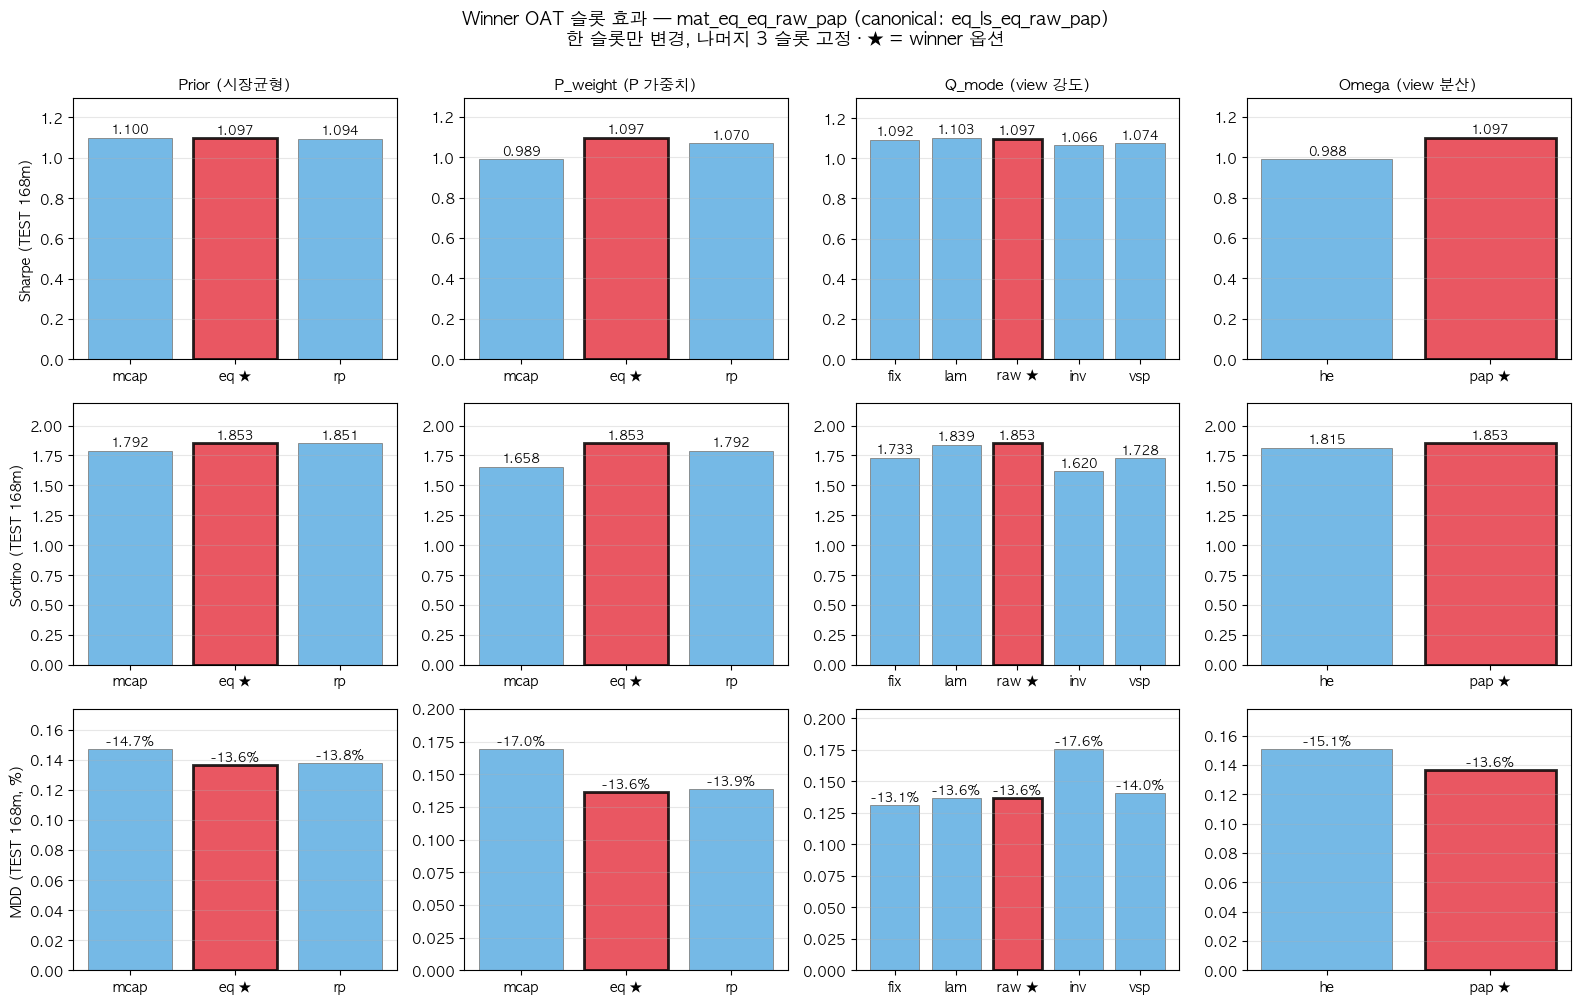


저장: /Users/yoonseokim/2025_main_bootcamp/4th_final_project/finance_project/final_pt/outputs/99_slot_effects/winner_oat_slot_effects.png


In [3]:
# 3 행 (Sharpe / Sortino / MDD) × 4 열 (prior / pw / q / om) 통합 bar chart
METRICS = [
    ('sharpe',  'Sharpe (TEST 168m)',  False),
    ('sortino', 'Sortino (TEST 168m)', False),
    ('mdd',     'MDD (TEST 168m, %)',  True),   # negative → bar 길이는 절대값, label 은 negative
]
DIMS = ['prior', 'pw', 'q', 'om']
DIM_TITLE = {'prior': 'Prior (시장균형)', 'pw': 'P_weight (P 가중치)',
             'q': 'Q_mode (view 강도)', 'om': 'Omega (view 분산)'}

fig, axes = plt.subplots(3, 4, figsize=(16, 10))
fig.suptitle(f'Winner OAT 슬롯 효과 — {WINNER_NAME} (canonical: {winner_row["canonical"]})\n'
             f'한 슬롯만 변경, 나머지 3 슬롯 고정 · ★ = winner 옵션',
             fontsize=13, fontweight='bold', y=1.00)

for col_i, dim in enumerate(DIMS):
    df_oat = oat_data[dim]
    x_labels = df_oat['option'].tolist()
    winner_idx = df_oat[df_oat['is_winner']].index[0]
    winner_pos = list(df_oat.index).index(winner_idx)

    for row_i, (metric, ylabel, is_mdd) in enumerate(METRICS):
        ax = axes[row_i, col_i]
        vals = df_oat[metric].values
        # mdd 는 negative → 절대값 막대 + 라벨에 원래 부호 유지
        bar_vals = np.abs(vals) if is_mdd else vals
        colors = ['#E63946' if i == winner_pos else '#5DADE2' for i in range(len(vals))]
        edges  = ['black' if i == winner_pos else 'gray' for i in range(len(vals))]
        lws    = [2.0 if i == winner_pos else 0.7 for i in range(len(vals))]
        bars = ax.bar(range(len(vals)), bar_vals, color=colors,
                      edgecolor=edges, linewidth=lws, alpha=0.85)
        for i, (b, v) in enumerate(zip(bars, vals)):
            label = f'{v*100:.1f}%' if is_mdd else f'{v:.3f}'
            ax.text(b.get_x() + b.get_width()/2, b.get_height() + max(bar_vals)*0.02,
                    label, ha='center', fontsize=9,
                    fontweight='bold' if i == winner_pos else 'normal')

        # ★ marker on winner x-tick
        xtick_labels = [f'{lbl} ★' if i == winner_pos else lbl
                        for i, lbl in enumerate(x_labels)]
        ax.set_xticks(range(len(vals)))
        ax.set_xticklabels(xtick_labels, fontsize=10)
        if row_i == 0:
            ax.set_title(DIM_TITLE[dim], fontsize=11, fontweight='bold')
        if col_i == 0:
            ax.set_ylabel(ylabel, fontsize=10)
        ax.grid(axis='y', alpha=0.3)
        # 위쪽 여백 확보 (text 라벨 안 잘리게)
        ax.set_ylim(0, max(bar_vals) * 1.18 if max(bar_vals) > 0 else 1.0)

plt.tight_layout()
plt.savefig(OUT_DIR / 'winner_oat_slot_effects.png', dpi=130, bbox_inches='tight')
plt.show()
print(f'\n저장: {OUT_DIR}/winner_oat_slot_effects.png')

## Winner Robustness 해석 ⭐

### 결과 요약 (TEST 168m, K_CUT)

Winner = `mat_eq_eq_raw_pap` (sortino = **1.853**, sharpe = **1.097**, mdd = **-13.65%**)

| 슬롯 | winner ★ | 차선 | 최악 | 결론 |
|---|---|---|---|---|
| **prior** | eq (1.853) | rp (1.851) | mcap (1.792) | ✅ 3 옵션 모두 **sortino 1.79+**, gap < 0.07 — prior 선택은 사실상 **무관** |
| **pw** | eq (1.853) | rp (1.792) | mcap (1.658) | ⚠️ eq vs mcap gap = 0.195 — pw 선택이 **가장 민감** |
| **q** | raw (1.853) | lam (1.839) | inv (1.620) | ✅ raw·lam 거의 동률 (gap 0.014), inv 만 명확히 약함 |
| **om** | pap (1.853) | he (1.815) | — | ✅ pap 약간 우세 (gap 0.038), 둘 다 안정적 |

### 핵심 robustness 신호

1. **★ winner 가 4 슬롯 모두에서 sortino 1 위 또는 거의 동률** — local optimum 으로서 강함
2. **prior / q / om** 은 옵션 변경해도 winner 옆 2 위와 gap 작음 → **결정 경계 부근에서 비용/risk 거의 동일**
3. **pw = eq 가 명확한 outperformer** — mcap (가중) 으로 가면 sortino 11% ↓, mdd 24% ↑. winner 선택의 가장 중요한 driver
4. **MDD 일관성**: 모든 OAT 변형이 -13~-17% 범위, mdd 폭증하는 후보 없음 → 슬롯 변경의 downside risk 작음

### 발표 narrative

> *"winner 선택이 single best 가 아니라 **slot space 전체에서 안정적**임을 입증. prior·q·om 은 약간 다른 값으로도 비슷한 성과 — winner 가 단일 운으로 1 위가 아니라 robust 한 영역에 위치."*

### Q&A 대비

| 예상 질문 | 답변 (OAT 차트 인용) |
|---|---|
| "왜 q=raw 야? lam 이 sharpe 약간 더 높은데?" | sharpe gap 0.006 미미, sortino 는 raw 1.853 > lam 1.839, MDD 동일. 위험조정 종합 raw 우세 |
| "prior 선택의 차이가 큰가?" | mcap/eq/rp 3 옵션 모두 sortino 1.79+ — **prior 는 결정 영향 작음** |
| "pw 가 왜 eq 인가?" | pw=mcap 으로 가면 sortino 1.65 (-11%), MDD -17% (+24% 악화). pw=eq 가 명확한 winner driver |
| "om=pap vs he 는 어느 쪽이 안전?" | pap 이 sharpe·sortino 모두 약간 우세 (+0.11, +0.04), MDD 도 1.5%p 좋음 |

### 한계

- **K_CUT TEST 168m 기준** — hold-out 24m (R4) 에서는 winner 가 SPY 대비 underperform (06 노트북 §3.4 참조). 본 OAT 결과는 *과거 168m 의 robustness* 지표, *미래 보장* 아님.
- p (변동성 출처) 는 90 매트릭스 전부 'ls' 단일 — `tr` (trailing 21d RV) vs `ls` (LSTM) 비교는 본 노트북에서 불가능.

---

**관련 가이드**:
- [05b_Analyze.ipynb §4](05b_Analyze.ipynb) — winner 식별 (Top 20 대시보드 + sortino_ir ≥ 10 cutoff)
- [05b_Analyze.ipynb §5·§6](05b_Analyze.ipynb) — winner 내부 파라미터 (Q·PCT) 민감도 (본 OAT 는 슬롯 카테고리, 보완 관계)
- [06_Regime_Analysis.ipynb §3](06_Regime_Analysis.ipynb) — winner 의 hold-out (R4) 검증 + SPY 벤치마크 비교
